In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_with_rul.csv"
)

train_df.head()

,unit_number,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,321,320
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321,319
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321,318
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321,317
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321,316


In [3]:
sensor_cols = [
    col for col in train_df.columns
    if "sensor_" in col
]

len(sensor_cols)

21

In [4]:
variance_df = pd.DataFrame({
    "sensor": sensor_cols,
    "variance": [
        train_df[col].var()
        for col in sensor_cols
    ]
})

variance_df.sort_values(
    "variance"
).head(10)

,sensor,variance
15,sensor_16,0.000022
9,sensor_10,0.016302
14,sensor_15,0.563061
10,sensor_11,10.520237
4,sensor_5,13.125202
18,sensor_19,28.830710
5,sensor_6,29.637316
20,sensor_21,35.553759
19,sensor_20,98.731968
0,sensor_1,698.906067


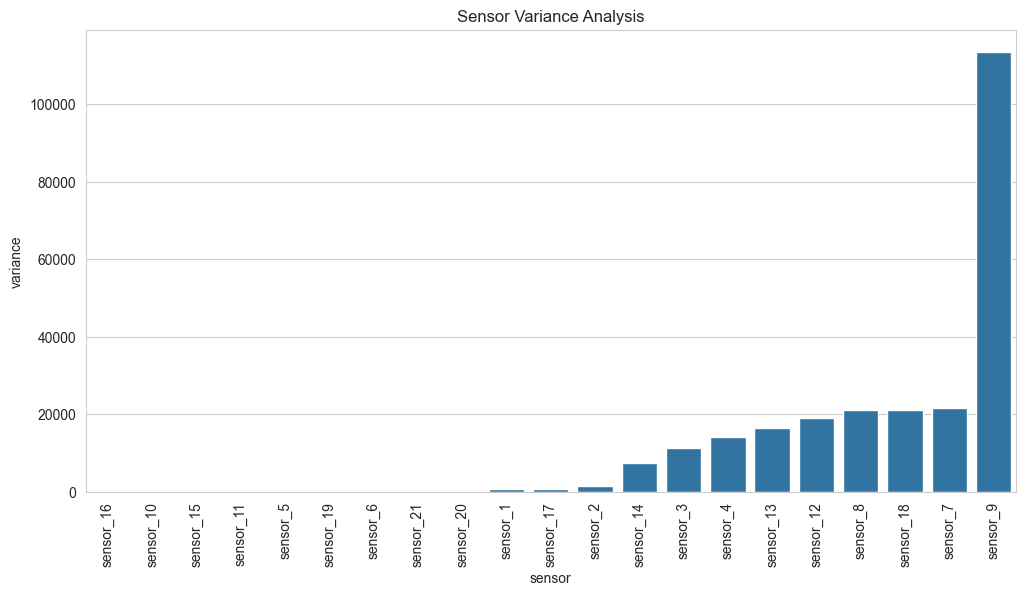

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=variance_df.sort_values("variance"),
    x="sensor",
    y="variance"
)

plt.xticks(rotation=90)
plt.title("Sensor Variance Analysis")

plt.show()

In [6]:
corr_with_rul = (
    train_df[sensor_cols + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values(
        key=abs,
        ascending=False
    )
)

corr_with_rul.head(15)

sensor_14   -0.078126
sensor_11   -0.056639
sensor_16   -0.053804
sensor_4    -0.045881
sensor_17   -0.032939
sensor_3    -0.032924
sensor_9    -0.024727
sensor_10   -0.008924
sensor_2    -0.004443
sensor_15   -0.003957
sensor_20    0.002812
sensor_21    0.002791
sensor_18    0.002765
sensor_19    0.002303
sensor_8     0.002086
Name: RUL, dtype: float64

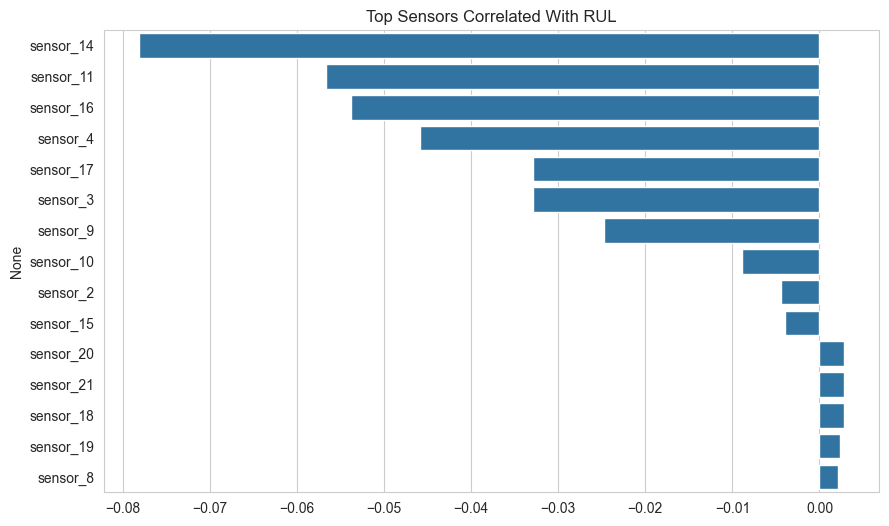

In [7]:
top_corr = corr_with_rul.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title(
    "Top Sensors Correlated With RUL"
)

plt.show()

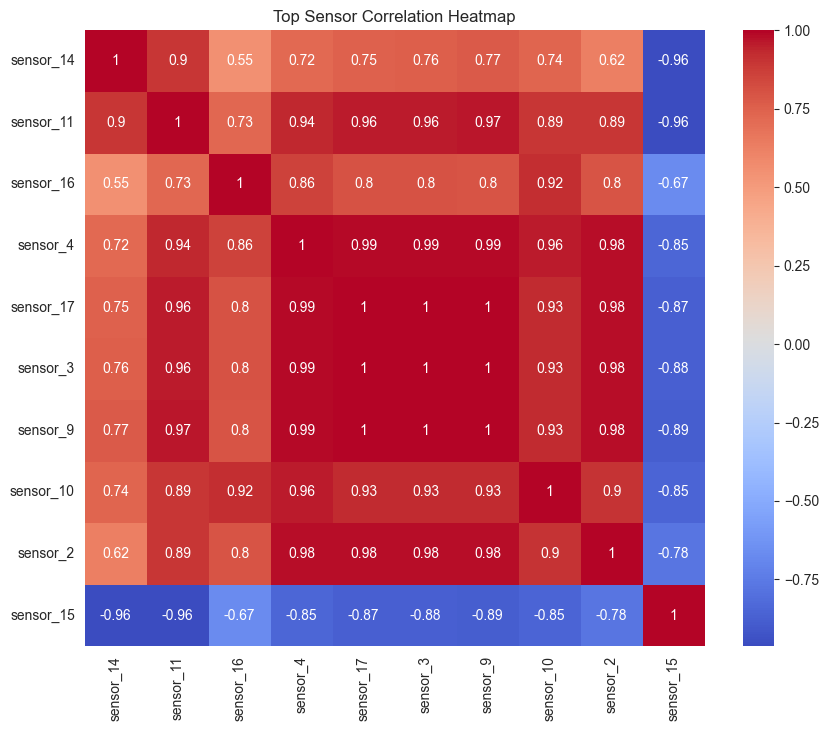

In [8]:
top_sensors = list(
    corr_with_rul.head(10).index
)

plt.figure(figsize=(10,8))

sns.heatmap(
    train_df[top_sensors].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Top Sensor Correlation Heatmap"
)

plt.show()

In [9]:
top_sensors = list(
    corr_with_rul.head(4).index
)

top_sensors

['sensor_14', 'sensor_11', 'sensor_16', 'sensor_4']

In [10]:
avg_profile = (
    train_df.groupby("RUL")[top_sensors]
    .mean()
    .reset_index()
)

avg_profile = avg_profile.sort_values(
    "RUL",
    ascending=False
)

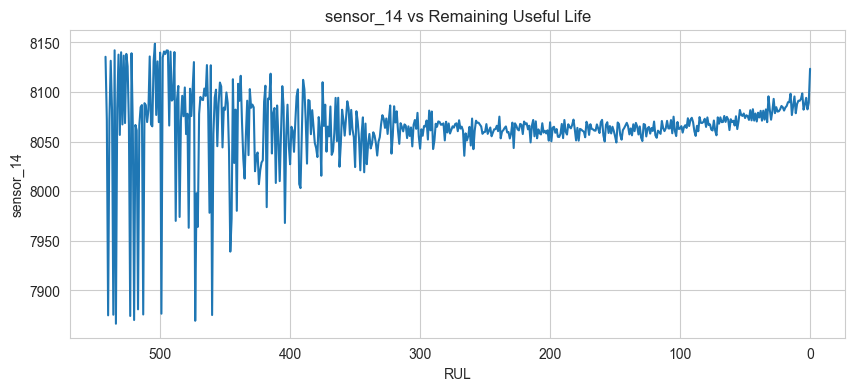

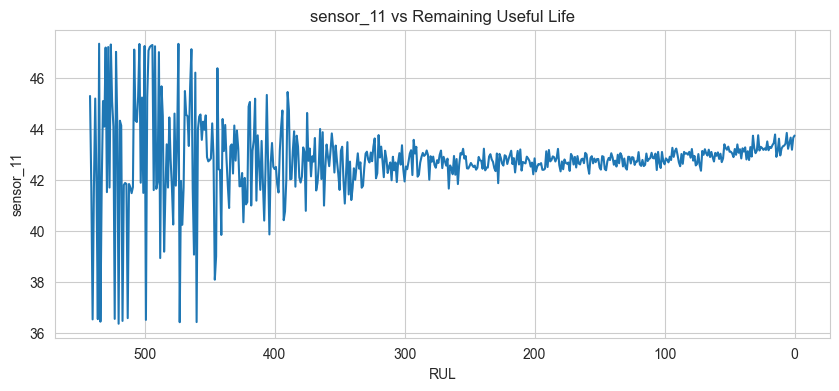

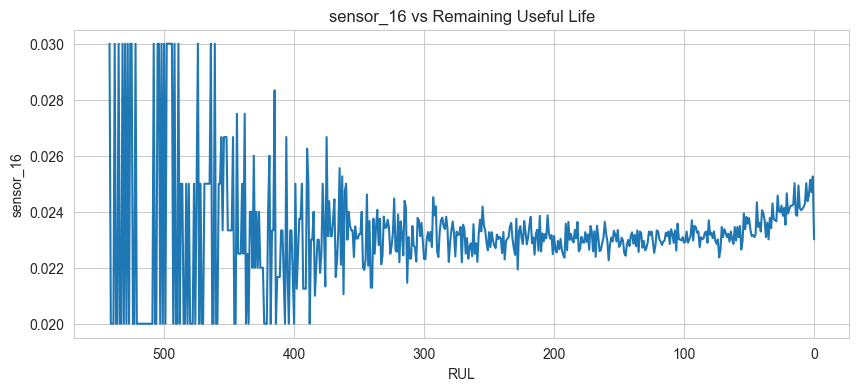

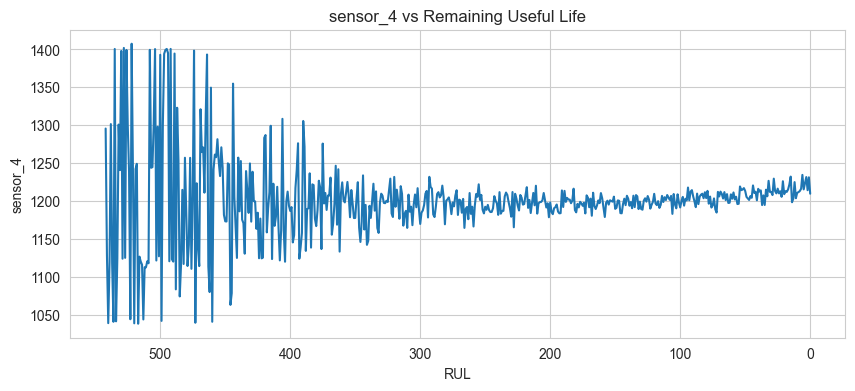

In [11]:
for sensor in top_sensors:

    plt.figure(figsize=(10,4))

    plt.plot(
        avg_profile["RUL"],
        avg_profile[sensor]
    )

    plt.gca().invert_xaxis()

    plt.title(
        f"{sensor} vs Remaining Useful Life"
    )

    plt.xlabel("RUL")
    plt.ylabel(sensor)

    plt.show()

In [12]:
healthy = train_df[
    train_df["RUL"] > 150
]

failing = train_df[
    train_df["RUL"] < 20
]

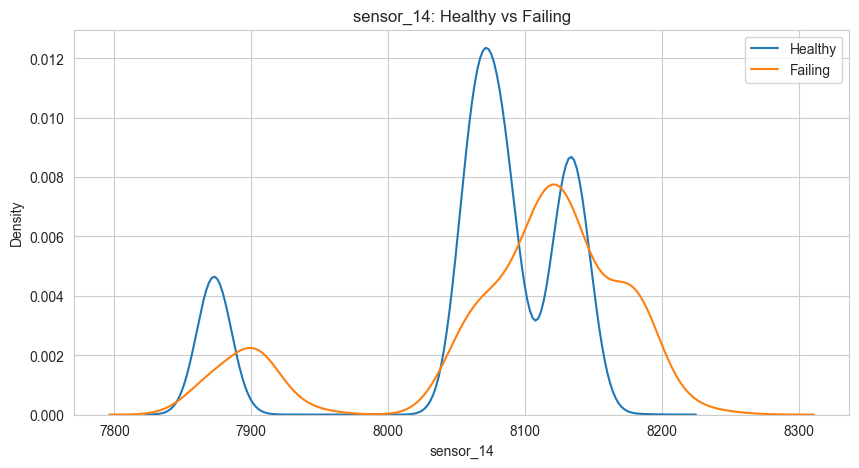

In [13]:
sensor = corr_with_rul.index[0]

plt.figure(figsize=(10,5))

sns.kdeplot(
    healthy[sensor],
    label="Healthy"
)

sns.kdeplot(
    failing[sensor],
    label="Failing"
)

plt.legend()

plt.title(
    f"{sensor}: Healthy vs Failing"
)

plt.show()

In [14]:
sample = train_df.sample(
    10000,
    random_state=42
)

X = sample[sensor_cols]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

components = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "PC1": components[:,0],
    "PC2": components[:,1],
    "RUL": sample["RUL"].values
})

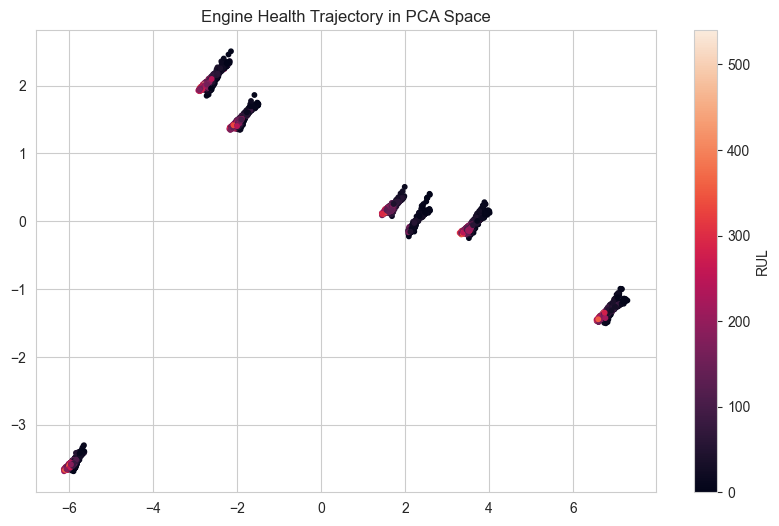

In [15]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["RUL"],
    s=10
)

plt.colorbar(
    scatter,
    label="RUL"
)

plt.title(
    "Engine Health Trajectory in PCA Space"
)

plt.show()

In [16]:
important_sensors = list(
    corr_with_rul.head(10).index
)

important_sensors

['sensor_14',
 'sensor_11',
 'sensor_16',
 'sensor_4',
 'sensor_17',
 'sensor_3',
 'sensor_9',
 'sensor_10',
 'sensor_2',
 'sensor_15']

## Key Findings

1. Several sensors exhibit strong correlation with RUL.

2. Certain sensors show monotonic degradation patterns as engines approach failure.

3. Healthy and failing engines occupy different regions in feature space.

4. PCA reveals a clear degradation trajectory from healthy operation toward failure.

5. Low-variance sensors may be removed during feature engineering.

In [18]:
corr_with_rul.head(10)

sensor_14   -0.078126
sensor_11   -0.056639
sensor_16   -0.053804
sensor_4    -0.045881
sensor_17   -0.032939
sensor_3    -0.032924
sensor_9    -0.024727
sensor_10   -0.008924
sensor_2    -0.004443
sensor_15   -0.003957
Name: RUL, dtype: float64

In [19]:
variance_df.sort_values("variance").head(10)

,sensor,variance
15,sensor_16,0.000022
9,sensor_10,0.016302
14,sensor_15,0.563061
10,sensor_11,10.520237
4,sensor_5,13.125202
18,sensor_19,28.830710
5,sensor_6,29.637316
20,sensor_21,35.553759
19,sensor_20,98.731968
0,sensor_1,698.906067


In [20]:
corr_with_rul.abs().sort_values(
    ascending=False
).head(20)

sensor_14    0.078126
sensor_11    0.056639
sensor_16    0.053804
sensor_4     0.045881
sensor_17    0.032939
sensor_3     0.032924
sensor_9     0.024727
sensor_10    0.008924
sensor_2     0.004443
sensor_15    0.003957
sensor_20    0.002812
sensor_21    0.002791
sensor_18    0.002765
sensor_19    0.002303
sensor_8     0.002086
sensor_1     0.001889
sensor_5     0.001679
sensor_12    0.001639
sensor_13    0.001501
sensor_7     0.001429
Name: RUL, dtype: float64

In [21]:
train_df[
    ["op_setting_1",
     "op_setting_2",
     "op_setting_3"]
].describe()

,op_setting_1,op_setting_2,op_setting_3
count,61249.000000,61249.000000,61249.000000
mean,23.999823,0.571347,94.031576
std,14.780722,0.310703,14.251954
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001400,0.700000,100.000000
75%,41.998100,0.840000,100.000000
max,42.008000,0.842000,100.000000


In [22]:
low_variance = variance_df[
    variance_df["variance"] < 1
]

low_variance

,sensor,variance
9,sensor_10,0.016302
14,sensor_15,0.563061
15,sensor_16,0.000022


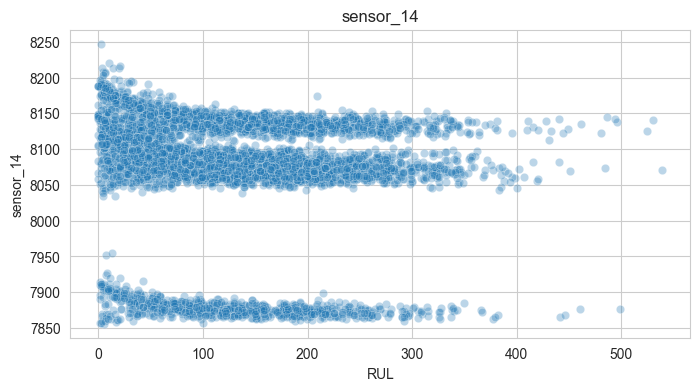

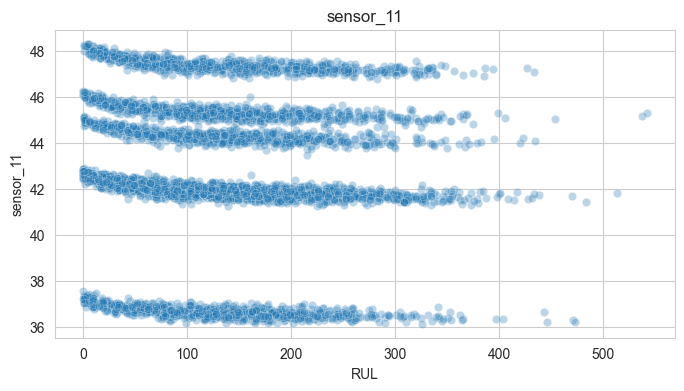

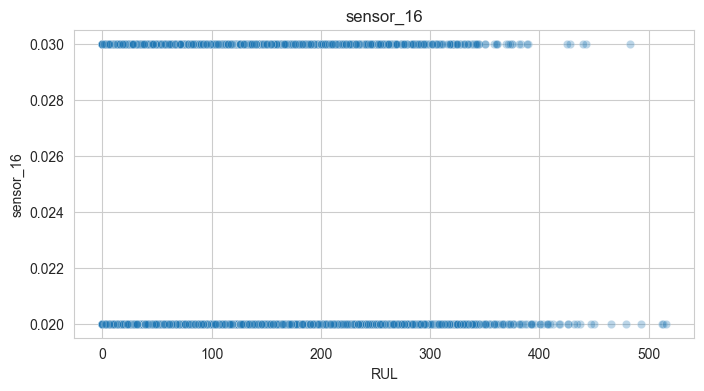

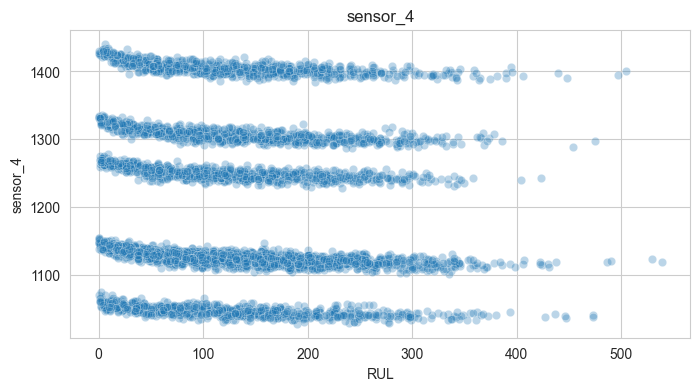

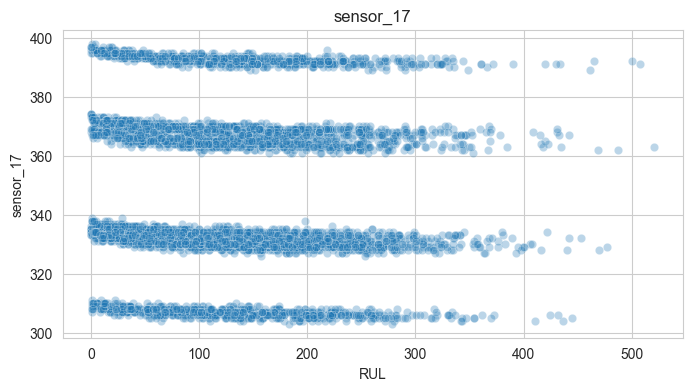

In [23]:
for sensor in corr_with_rul.head(5).index:

    plt.figure(figsize=(8,4))

    sns.scatterplot(
        data=train_df.sample(5000),
        x="RUL",
        y=sensor,
        alpha=0.3
    )

    plt.title(sensor)

    plt.show()